# 🌾 PIPELINE TỰ ĐỘNG TRÍCH XUẤT ĐẶC TRƯNG DATASET AI (RICE VISION AI V2.5)
**Đề tài Nghiên cứu Khoa học**: Hệ thống thị giác máy tính và học sâu phục vụ ước lượng số lượng và đánh giá phẩm cấp hạt giống lúa.

---

### 🎯 Quy trình Hoạt động & Mục tiêu:
1. **Khảo sát ảnh thô**: Kiểm kê theo từng `Sample_ID`, hỗ trợ ảnh phẳng mới (ví dụ `M0001.jpg`) và cấu trúc legacy.
2. **Duyệt qua từng mẫu** trong file Excel dữ liệu nhập tay `2_Manual_Records/manual_data.xlsx`.
3. **Đối chiếu ảnh chụp**: Ưu tiên tìm `1_Raw_Images/<Sample_ID>.jpg`; vẫn hỗ trợ ảnh legacy tại `1_Raw_Images/M###/M###X.jpg`.
   - ⚪ *Nếu chưa có ảnh*: Tự động để trống toàn bộ các trường trích xuất AI (NaN / blank) để chụp bổ sung sau.
   - 🟢 *Nếu đã có ảnh*: Tiến hành bóc tách và trích xuất qua 2 giai đoạn chuẩn hóa:
4. **Giai đoạn 1 (Bóc tách, 2 lần Clean & Sàng lọc Hạt Nguyên - Tăng tốc GPU)**:
   - Nhận diện miệng ly bằng thuật toán đồng tâm hình học chuẩn xác.
   - Bóc tách polygon hạt lúa bằng **SAHI + YOLO-seg trên GPU (cuda:0)**.
   - Khử nhiễu qua **2 lần Clean chuyên sâu (Step 1 + Step 2)** bẻ eo dính và lọc mảnh vụn.
   - Phân loại bằng **DenseNet121 CNN (`best_v3_step2.keras`) trên GPU** $\to$ Lưu ảnh **HẠT NGUYÊN** vào `3_AI_Extracted/CROPPED_GRAINS/M###/M###X/`.
5. **Điểm Dừng & Kiểm Duyệt Thủ Công (Human-in-the-loop QA)**:
   - Bạn mở thư mục xem mắt thường các ảnh hạt nguyên, tự tay xóa hạt dính chùm hoặc mẩu vụn (nếu có).
   - Chạy script `check_filtered_grains.py` để kiểm kê số lượng hạt nguyên sau khi lọc.
6. **Giai đoạn 2 (Tính toán Đặc trưng 2D/3D & Xuất Dataset Cuối)**:
   - Đo đạc kích thước 2D/3D (Dài, Rộng, Dày, Diện tích: Mean, Min, Max, Std).
   - Mô hình hóa thể tích 3D Ellipsoid ($V = \frac{4}{3}\pi abc$: Mean, Min, Max, Std) **chuyên biệt cho tập hạt nguyên**.
   - Ghép nối dữ liệu nhập tay và xuất bộ dữ liệu hoàn chỉnh sang `4_Final_Dataset/final_linear_regression_dataset.xlsx`.


In [1]:
# Bước 1: Kết nối Google Drive & Cài đặt thư viện
from google.colab import drive
import os

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

!pip install ultralytics sahi tensorflow openpyxl matplotlib seaborn opencv-python numpy pandas


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.1 MB/s eta 0:00:00


In [2]:
# Bước 2: Khai báo Đường dẫn, Import Modules & Kiểm tra GPU
import os
import sys
import torch
import tensorflow as tf
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.patches as mpatches

# CẤU HÌNH ĐƯỜNG DẪN DỰ ÁN TRÊN GOOGLE DRIVE / LOCAL
BASE_PATH = "/content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES"

code_dir = os.path.join(BASE_PATH, "CODE")
builder_dir = os.path.join(BASE_PATH, "DATASET_BUILDER")
for p in [code_dir, builder_dir]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Tự động reload các module nghiệp vụ
import modules.container_detector
import modules.grain_segmenter
import modules.grain_crop_cleaner
import modules.grain_classifier
import modules.ellipsoid_geometry
import modules.uniformity_evaluator
import modules.dataset_extractor

for mod in [
    modules.container_detector,
    modules.grain_segmenter,
    modules.grain_crop_cleaner,
    modules.grain_classifier,
    modules.ellipsoid_geometry,
    modules.uniformity_evaluator,
    modules.dataset_extractor
]:
    importlib.reload(mod)

from modules.dataset_extractor import DatasetExtractor

# KIỂM TRA THIẾT BỊ GPU
gpu_available = torch.cuda.is_available()
gpu_name = torch.cuda.get_device_name(0) if gpu_available else "CPU (Không có GPU)"

# ĐƯỜNG DẪN TRỌNG SỐ MÔ HÌNH
YOLO_MODEL_PATH = os.path.join(BASE_PATH, "RESULTS/all-new-data-v1.yolov8_yolov8s-seg_trained/weights/best.pt")
if not os.path.exists(YOLO_MODEL_PATH):
    YOLO_MODEL_PATH = os.path.join(BASE_PATH, "RESULTS/35_special_images_segmentation.v1i.yolov8_v1_trained/weights/best.pt")

CNN_MODEL_PATH = os.path.join(BASE_PATH, "RESULTS/CNN_DenseNet121_Trained/best_v3_step2.keras")

print("=" * 70)
print(f"📁 Thư mục gốc dự án  : {BASE_PATH}")
print(f"⚡ Trạng thái GPU     : {'✅ ' + gpu_name if gpu_available else '❌ CHƯA BẬT GPU (Vào Runtime -> Change runtime type -> T4 GPU)'}")
print(f"🎯 Trọng số YOLO-seg  : {YOLO_MODEL_PATH}")
print(f"🧠 Trọng số CNN       : {CNN_MODEL_PATH}")
print("=" * 70)


📁 Thư mục gốc dự án  : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES
⚡ Trạng thái GPU     : ✅ Tesla T4
🎯 Trọng số YOLO-seg  : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/all-new-data-v1.yolov8_yolov8s-seg_trained/weights/best.pt
🧠 Trọng số CNN       : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/CNN_DenseNet121_Trained/best_v3_step2.keras


📊 BÁO CÁO KHẢO SÁT SỐ LƯỢNG ẢNH THÔ (1_Raw_Images) — CHUẨN 5 ẢNH/MẪU
🔹 Tổng số mã mẫu thực tế        : 57 mã (từ M001 đến M057)
🔹 Tổng số ảnh hiện có           : 261 / 285 ảnh kỳ vọng (91.6%)
🔹 Số mẫu ĐỦ CHUẨN hoặc THỪA (>=5): 46 mã (80.7%)
🔹 Số mẫu ĐANG THIẾU ẢNH (<5)    : 11 mã (19.3%)
🔹 Số mẫu CHƯA CÓ ẢNH (0 ảnh)    : 0 mã
💾 Đã lưu báo cáo chi tiết vào   : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DATASET_BUILDER/3_AI_Extracted/raw_images_inventory_report.csv

⚠️ DANH SÁCH 11 MÃ MẪU ĐANG BỊ THIẾU ẢNH (CẦN BỔ SUNG NẾU CÓ):



,Mã_Mẫu,Số_Ảnh_Hiện_Có,Trạng_Thái,Ảnh_Còn_Thiếu
24,M025,2,THIẾU (2/5),"C, D, E"
25,M026,2,THIẾU (2/5),"C, D, E"
26,M027,3,THIẾU (3/5),"D, E"
29,M030,2,THIẾU (2/5),"C, D, E"
30,M031,2,THIẾU (2/5),"C, D, E"
31,M032,2,THIẾU (2/5),"C, D, E"
33,M034,2,THIẾU (2/5),"C, D, E"
34,M035,2,THIẾU (2/5),"C, D, E"
35,M036,2,THIẾU (2/5),"C, D, E"
38,M039,1,THIẾU (1/5),"B, C, D, E"


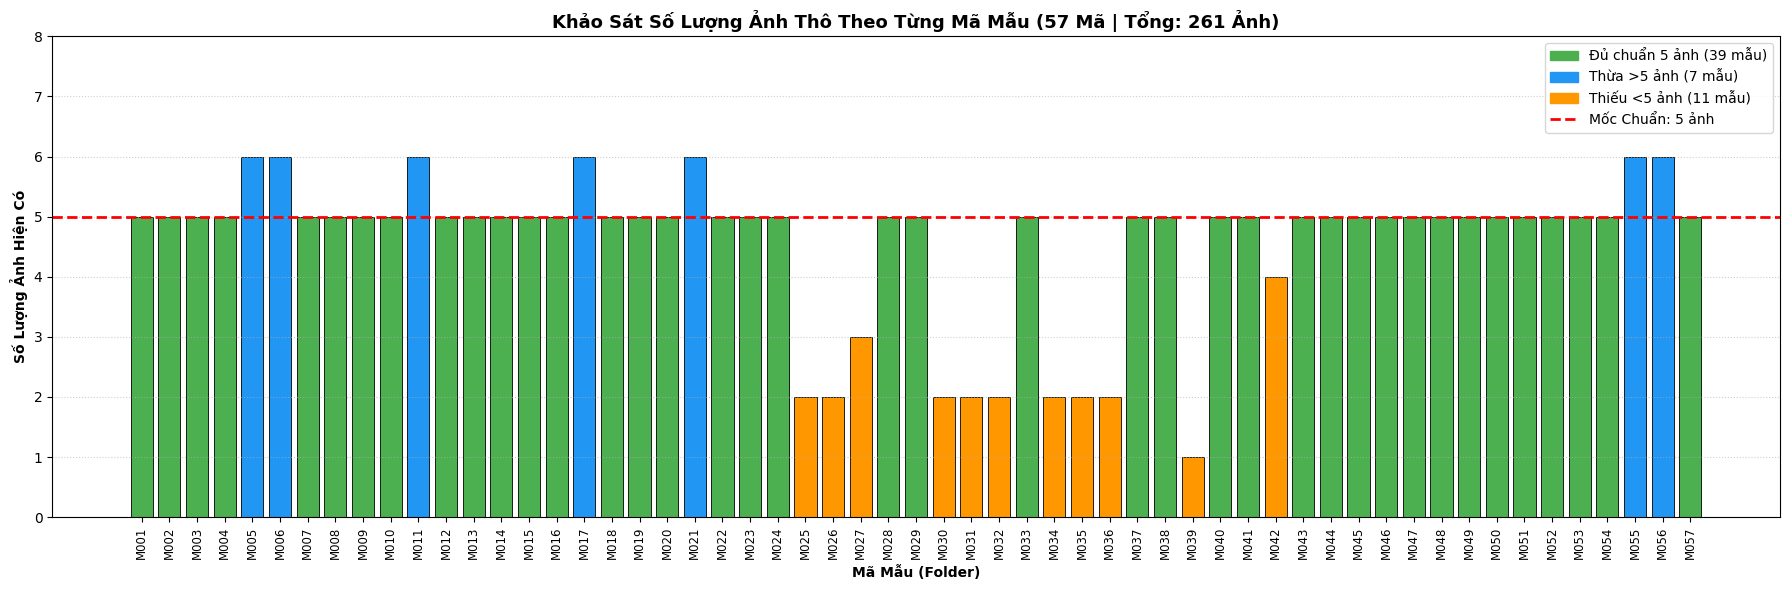

💾 Đã lưu biểu đồ khảo sát ảnh vào: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DATASET_BUILDER/3_AI_Extracted/raw_images_inventory_chart.png


In [3]:
# Bước 3: KIỂM KÊ ẢNH THÔ THEO MÃ ẢNH (HỖ TRỢ ẢNH PHẲNG VÀ DỮ LIỆU LEGACY)
# Capture App mới lưu một ảnh cho mỗi Sample_ID, ví dụ M0001.jpg.
# Dữ liệu cũ M001/M001A.jpg vẫn được đọc để có thể xử lý song song.
from collections import defaultdict
import re

raw_dir = Path(BASE_PATH) / 'DATASET_BUILDER' / '1_Raw_Images'
survey_out_dir = Path(BASE_PATH) / 'DATASET_BUILDER' / '3_AI_Extracted'
survey_out_dir.mkdir(parents=True, exist_ok=True)
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
images_by_id = defaultdict(list)

# Đọc ảnh mới ở thư mục gốc và ảnh cũ trong thư mục M001, M002, ...
for raw_item in sorted(raw_dir.iterdir(), key=lambda path: path.name.upper()):
    if raw_item.is_file() and raw_item.suffix.lower() in image_extensions:
        images_by_id[raw_item.stem.upper()].append((raw_item, 'Phẳng'))
    elif raw_item.is_dir() and raw_item.name.upper().startswith('M'):
        for image_file in sorted(raw_item.iterdir(), key=lambda path: path.name.upper()):
            if image_file.is_file() and image_file.suffix.lower() in image_extensions:
                images_by_id[image_file.stem.upper()].append((image_file, f'Legacy: {raw_item.name}/'))

# Bổ sung các mã đã nhập vào Excel để phát hiện trường hợp có bản ghi nhưng chưa có ảnh.
manual_ids = set()
try:
    survey_reader = DatasetExtractor(
        base_dir=BASE_PATH, yolo_model_path=YOLO_MODEL_PATH, cnn_model_path=CNN_MODEL_PATH
    )
    manual_ids = {str(record['Sample_ID']).strip().upper() for record in survey_reader.read_manual_records() if record.get('Sample_ID')}
except Exception as exc:
    print(f'⚠️ Không thể đọc Excel để đối chiếu: {exc}')

def sample_sort_key(sample_id):
    match = re.fullmatch(r'([A-Z]+)(\d+)([A-Z]*)', sample_id)
    return (match.group(1), int(match.group(2)), match.group(3)) if match else (sample_id, 0, '')

all_sample_ids = sorted(set(images_by_id) | manual_ids, key=sample_sort_key)
survey_records = []
for sample_id in all_sample_ids:
    entries = images_by_id.get(sample_id, [])
    image_count = len(entries)
    if image_count == 0:
        status = 'CHƯA CÓ ẢNH'
    elif image_count == 1:
        status = 'SẴN SÀNG XỬ LÝ'
    else:
        status = 'TRÙNG MÃ / NHIỀU ẢNH CÙNG MÃ'

    survey_records.append({
        'Sample_ID': sample_id,
        'Có_trong_Excel': 'Có' if sample_id in manual_ids else 'Chưa',
        'Số_Ảnh_Gốc': image_count,
        'Trạng_Thái': status,
        'Vị_Trí_Lưu': '; '.join(f'{storage} {image_path.relative_to(raw_dir)}' for image_path, storage in entries) or '-',
        'Danh_Sách_File': '; '.join(image_path.name for image_path, _storage in entries) or '-',
    })

report_columns = ['Sample_ID', 'Có_trong_Excel', 'Số_Ảnh_Gốc', 'Trạng_Thái', 'Vị_Trí_Lưu', 'Danh_Sách_File']
df_survey = pd.DataFrame(survey_records, columns=report_columns)
survey_csv_path = survey_out_dir / 'raw_images_inventory_report.csv'
df_survey.to_csv(survey_csv_path, index=False, encoding='utf-8-sig')

ready_count = int((df_survey['Trạng_Thái'] == 'SẴN SÀNG XỬ LÝ').sum()) if not df_survey.empty else 0
missing_images = df_survey[df_survey['Trạng_Thái'] == 'CHƯA CÓ ẢNH']
duplicate_images = df_survey[df_survey['Trạng_Thái'] == 'TRÙNG MÃ / NHIỀU ẢNH CÙNG MÃ']
total_images = int(df_survey['Số_Ảnh_Gốc'].sum()) if not df_survey.empty else 0

print('=' * 80)
print('📊 BÁO CÁO KIỂM KÊ ẢNH THÔ (1_Raw_Images)')
print('=' * 80)
print(f'🔹 Tổng số Sample_ID được kiểm kê : {len(df_survey)}')
print(f'🔹 Tổng số ảnh phát hiện           : {total_images}')
print(f'🔹 Mã sẵn sàng xử lý (1 ảnh/mã)    : {ready_count}')
print(f'🔹 Mã có Excel nhưng thiếu ảnh     : {len(missing_images)}')
print(f'🔹 Mã trùng/nhiều ảnh cần rà soát  : {len(duplicate_images)}')
print(f'💾 Đã lưu báo cáo chi tiết vào     : {survey_csv_path}')
print('=' * 80)

needs_review = df_survey[df_survey['Trạng_Thái'] != 'SẴN SÀNG XỬ LÝ']
if not needs_review.empty:
    print('\n⚠️ CÁC MÃ CẦN KIỂM TRA:')
    display(needs_review[['Sample_ID', 'Có_trong_Excel', 'Số_Ảnh_Gốc', 'Trạng_Thái', 'Vị_Trí_Lưu']])

# Biểu đồ chỉ thể hiện số ảnh thực tế, không còn giả định 5 ảnh A-E.
if not df_survey.empty:
    color_map = {
        'SẴN SÀNG XỬ LÝ': '#4CAF50',
        'CHƯA CÓ ẢNH': '#F44336',
        'TRÙNG MÃ / NHIỀU ẢNH CÙNG MÃ': '#FF9800',
    }
    plt.figure(figsize=(max(12, len(df_survey) * 0.38), 6))
    plt.bar(
        df_survey['Sample_ID'], df_survey['Số_Ảnh_Gốc'],
        color=[color_map[status] for status in df_survey['Trạng_Thái']],
        edgecolor='black', linewidth=0.6,
    )
    plt.title(f'Kiểm Kê Ảnh Thô Theo Sample_ID ({len(df_survey)} mã | {total_images} ảnh)', fontweight='bold', fontsize=13)
    plt.xlabel('Sample_ID', fontweight='bold')
    plt.ylabel('Số ảnh gốc', fontweight='bold')
    plt.xticks(rotation=90, fontsize=8.5)
    plt.ylim(0, max(2, int(df_survey['Số_Ảnh_Gốc'].max()) + 1))
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.legend(handles=[
        mpatches.Patch(color='#4CAF50', label='1 ảnh, sẵn sàng xử lý'),
        mpatches.Patch(color='#F44336', label='Chưa có ảnh'),
        mpatches.Patch(color='#FF9800', label='Trùng/nhiều ảnh cùng mã'),
    ], loc='upper right')
    plt.tight_layout()
    survey_chart_path = survey_out_dir / 'raw_images_inventory_chart.png'
    plt.savefig(survey_chart_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Đã lưu biểu đồ khảo sát ảnh vào: {survey_chart_path}')


In [ ]:
# Bước 4: Khởi tạo Bộ điều phối Dataset Extractor (Tự động kích hoạt GPU cuda:0)
extractor = DatasetExtractor(
    base_dir=BASE_PATH,
    yolo_model_path=YOLO_MODEL_PATH,
    cnn_model_path=CNN_MODEL_PATH,
    packing_fraction=0.80  # Hệ số chèn lấp khối lúa (~0.60 - 0.64)
)

# Nạp mô hình vào GPU
device_to_use = "cuda:0" if torch.cuda.is_available() else "cpu"
extractor.init_models(conf=0.50, device=device_to_use)


🚀 ĐANG KHỞI TẠO CÁC MÔ HÌNH THỊ GIÁC MÁY TÍNH...
   • YOLO Model : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/all-new-data-v1.yolov8_yolov8s-seg_trained/weights/best.pt
   • CNN Model  : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/CNN_DenseNet121_Trained/best_v3_step2.keras
   • Thiết bị   : cuda:0 (Tesla T4)
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
📦 Đang nạp mô hình CNN từ: /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/RESULTS/CNN_DenseNet121_Trained/best_v3_step2.keras...
✅ Nạp mô hình CNN thành công!
✨ Tất cả mô hình AI đã sẵn sàng hoạt động!



In [5]:
# Bước 5: [GIAI ĐOẠN 1] — Bóc tách SAHI (GPU), 2 lần Clean & Sàng lọc Hạt Nguyên lưu vào 3_AI_Extracted
# Quá trình này sẽ tự động:
#  1. Duyệt qua từng dòng trong manual_data.xlsx
#  2. Đối chiếu ảnh trong 1_Raw_Images (nếu chưa có ảnh thì tự động bỏ qua)
#  3. Bóc tách polygon từng hạt lúa bằng SAHI YOLO-seg trên GPU
#  4. Thực hiện 2 lần Clean (Step 1: k=5, area=35 -> Step 2: k=3, area=25)
#  5. Phân loại CNN v3_step2 và lưu riêng các hạt nguyên vào 3_AI_Extracted/CROPPED_GRAINS/M###/M###X/

# stage1_results = extractor.run_stage1_crop_and_classify(
#     conf_yolo=0.50,
#     slice_size=640,
#     overlap=0.25,
#     conf_cnn=0.50,
#     skip_existing=False  # Đổi True nếu muốn tiếp tục chạy nối tiếp các mẫu chưa chạy
# )


# 🔍 BƯỚC 6: ĐIỂM DỪNG TƯƠNG TÁC — KIỂM DUYỆT THỦ CÔNG (HUMAN-IN-THE-LOOP QA)
---
> **Hướng dẫn thực hiện**:
> 1. Bạn mở tab **Files** trên Google Colab hoặc truy cập trực tiếp Google Drive theo đường dẫn:
>    📁 `.../DATASET_BUILDER/3_AI_Extracted/CROPPED_GRAINS/`
> 2. Trong này chứa các thư mục con tương ứng với từng mẫu (ví dụ: `M001/M001A/`, `M001/M001B/`,...).
> 3. Bạn mở xem nhanh các ảnh hạt nguyên bên trong:
>    - Nếu thấy ảnh nào bị **dính chùm 2 hạt** hoặc **mẩu vụn ngoại lai**, bạn chỉ cần **bấm chuột phải và XÓA (Delete) file ảnh đó**.
>    - Những hạt còn lại trong folder sẽ là tập mẫu chuẩn tuyệt đối để tính toán kích thước 2D và thể tích 3D.
> 4. Chạy **Cell 6.1 bên dưới** để kiểm tra thống kê số lượng hạt nguyên sau khi lọc trước khi bấm chạy Giai đoạn 2!


In [6]:
# Bước 6.1: KIỂM TRA SỐ LƯỢNG HẠT NGUYÊN SAU KHI LỌC (DÙNG CHECK_FILTERED_GRAINS.PY)
from check_filtered_grains import audit_filtered_grains

audit_results = audit_filtered_grains(
    base_dir=Path(BASE_PATH),
    min_warning_threshold=3,  # Cảnh báo các mã có ít hơn 3 hạt nguyên
    verbose=False
)


🌾 CÔNG CỤ KIỂM TRA SỐ LƯỢNG HẠT NGUYÊN SAU LỌC (GRAIN AUDIT TOOL)
📁 Thư mục gốc       : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES
📁 Thư mục hạt crops : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DATASET_BUILDER/3_AI_Extracted/CROPPED_GRAINS

📊 BẢNG TỔNG HỢP KIỂM KÊ SỐ LƯỢNG HẠT NGUYÊN (SAU LỌC):
  • Tổng số mã ảnh được kiểm tra : 292 mã
  • Số mã ĐÃ CÓ HẠT NGUYÊN (✅)   : 253 mã
  • Tổng số hạt nguyên sạch      : 2208 hạt
  • Trung bình số hạt / 1 ảnh    : 8.7 hạt (Min: 1, Max: 18)
  • Số mã có 0 HẠT (🔴)          : 0 mã
  • Số mã ÍT HẠT (<3) (🟠)       : 11 mã
  • Số mã chưa có thư mục (⏳)   : 8 mã
💾 Đã lưu báo cáo chi tiết vào  : /content/drive/MyDrive/NGHIÊN CỨU KHOA HỌC/GROUP_MEMBERS/NGUYEN MINH TRI/MAIN_SOURCES/DATASET_BUILDER/3_AI_Extracted/filtered_grains_audit_report.csv

📋 CHI TIẾT SỐ LƯỢNG HẠT THEO TỪNG MÃ MẪU:
-----------------------------------------------------------------------------------

In [8]:
# Bước 7: [GIAI ĐOẠN 2] — Tính toán Đặc trưng 2D/3D & Ghép Dữ liệu Xuất ra 4_Final_Dataset
# Quá trình này sẽ tự động:
#  1. Đọc lại các ảnh hạt nguyên đã kiểm duyệt trong 3_AI_Extracted/CROPPED_GRAINS
#  2. Tính Mean, Min, Max, Std của Chiều dài (2a), Chiều rộng (2b), Chiều dày (2c), Diện tích 2D (mm²)
#  3. Tính Mean, Min, Max, Std của Thể tích 3D Ellipsoid V = (4/3)*pi*a*b*c (mm³)
#  4. Ghép nối với dữ liệu thủ công từ manual_data.xlsx (các mẫu chưa có ảnh sẽ để trống)
#  5. Xuất file kết quả hoàn chỉnh vào 4_Final_Dataset/final_linear_regression_dataset.xlsx và .csv

final_dataset_path = extractor.run_stage2_calculate_and_export(
    output_filename="final_linear_regression_dataset.xlsx",
    show_progress=True  # Hiển thị trực tiếp quá trình tính toán 2D/3D từng mẫu
)


📊 BẮT ĐẦU GIAI ĐOẠN 2: TÍNH TOÁN HÌNH THÁI HỌC 2D & THỂ TÍCH 3D ELLIPSOID
📋 Tổng số mẫu xử lý : 285 dòng

[001/285] 🌾 M001a    ->  7 hạt | Dài=5.33mm | Rộng=1.86mm | V_hạt=25.19mm³ | V_khối=5,723mm³
[002/285] 🌾 M001b    ->  5 hạt | Dài=5.47mm | Rộng=1.97mm | V_hạt=26.95mm³ | V_khối=5,723mm³
[003/285] 🌾 M001c    ->  5 hạt | Dài=5.39mm | Rộng=1.84mm | V_hạt=24.42mm³ | V_khối=5,723mm³
[004/285] 🌾 M001d    ->  5 hạt | Dài=5.48mm | Rộng=1.91mm | V_hạt=27.52mm³ | V_khối=5,723mm³
[005/285] 🌾 M001e    ->  4 hạt | Dài=5.80mm | Rộng=2.22mm | V_hạt=34.21mm³ | V_khối=5,723mm³
[006/285] 🌾 M002a    ->  4 hạt | Dài=6.88mm | Rộng=2.17mm | V_hạt=48.78mm³ | V_khối=6,694mm³
[007/285] 🌾 M002b    ->  5 hạt | Dài=5.96mm | Rộng=2.07mm | V_hạt=35.19mm³ | V_khối=6,694mm³
[008/285] 🌾 M002c    ->  8 hạt | Dài=6.19mm | Rộng=1.91mm | V_hạt=33.61mm³ | V_khối=6,694mm³
[009/285] 🌾 M002d    ->  6 hạt | Dài=6.19mm | Rộng=2.07mm | V_hạt=38.27mm³ | V_khối=6,694mm³
[010/285] 🌾 M002e    ->  9 hạt | Dài=6.03mm | Rộng=2.10mm

📊 TỔNG KẾT BẢNG DỮ LIỆU ĐÃ TRÍCH XUẤT CHO HỒI QUY TUYẾN TÍNH:
   • Tổng số mẫu trong danh sách : 285 mẫu
   • Số mẫu đã trích xuất AI     : 254 mẫu
   • Số mẫu đang chờ chụp thêm   : 31 mẫu


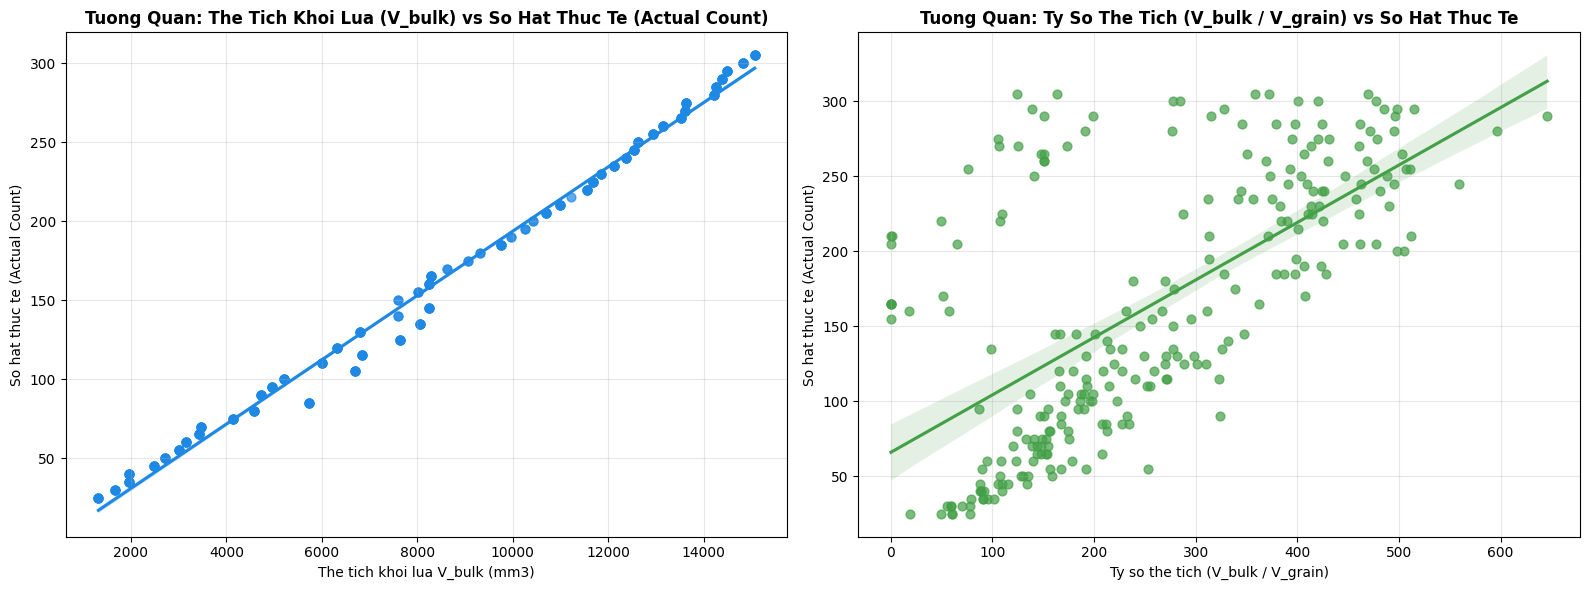


📈 [MA TRẬN HỆ SỐ TƯƠNG QUAN PEARSON PHỤC VỤ HUẤN LUYỆN LINEAR REGRESSION]:


,Actual_Count,Bulk_Rice_Volume_mm3,Grain_Volume_mm3_Mean,Volume_Ratio,Grain_Length_mm_Mean,Grain_Width_mm_Mean
Actual_Count,1.000000,0.995873,0.040680,0.644010,0.094942,0.077864
Bulk_Rice_Volume_mm3,0.995873,1.000000,0.037732,0.653292,0.091522,0.073819
Grain_Volume_mm3_Mean,0.040680,0.037732,1.000000,-0.301480,0.973281,0.965664
Volume_Ratio,0.644010,0.653292,-0.301480,1.000000,-0.349656,-0.360717
Grain_Length_mm_Mean,0.094942,0.091522,0.973281,-0.349656,1.000000,0.993618
Grain_Width_mm_Mean,0.077864,0.073819,0.965664,-0.360717,0.993618,1.000000


In [9]:
# Bước 8: Trực quan hóa & Phân tích Tương quan cho Mô hình Hồi Quy Tuyến Tính (Linear Regression)
csv_path = os.path.join(BASE_PATH, "DATASET_BUILDER/4_Final_Dataset/final_linear_regression_dataset.csv")
if not os.path.exists(csv_path):
    csv_path = os.path.join(BASE_PATH, "DATASET_BUILDER/3_AI_Extracted/ai_extracted_dataset.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df_valid = df[df['Image_Status'] == 'FOUND'].copy()

    print("=" * 80)
    print(f"📊 TỔNG KẾT BẢNG DỮ LIỆU ĐÃ TRÍCH XUẤT CHO HỒI QUY TUYẾN TÍNH:")
    print(f"   • Tổng số mẫu trong danh sách : {len(df)} mẫu")
    print(f"   • Số mẫu đã trích xuất AI     : {len(df_valid)} mẫu")
    print(f"   • Số mẫu đang chờ chụp thêm   : {len(df) - len(df_valid)} mẫu")
    print("=" * 80)

    # Chuyển đổi các cột số
    numeric_cols = [
        'Actual_Count', 'Bulk_Rice_Volume_mm3', 'Grain_Volume_mm3_Mean',
        'Grain_Length_mm_Mean', 'Grain_Width_mm_Mean', 'Grain_Thickness_mm_Mean',
        'Whole_Grains_Count', 'Estimated_Total_Seeds_Hybrid'
    ]
    for col in numeric_cols:
        if col in df_valid.columns:
            df_valid[col] = pd.to_numeric(df_valid[col], errors='coerce')

    df_clean = df_valid.dropna(subset=['Actual_Count', 'Bulk_Rice_Volume_mm3', 'Grain_Volume_mm3_Mean'])

    if len(df_clean) >= 2:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # 1. Biểu đồ tương quan Thể tích khối lúa vs Số hạt thực tế
        sns.regplot(
            data=df_clean,
            x='Bulk_Rice_Volume_mm3',
            y='Actual_Count',
            ax=axes[0],
            color='#1E88E5',
            scatter_kws={'alpha': 0.7, 's': 40}
        )
        axes[0].set_title("Tuong Quan: The Tich Khoi Lua (V_bulk) vs So Hat Thuc Te (Actual Count)", fontweight='bold')
        axes[0].set_xlabel("The tich khoi lua V_bulk (mm3)")
        axes[0].set_ylabel("So hat thuc te (Actual Count)")
        axes[0].grid(True, alpha=0.3)

        # 2. Biểu đồ tương quan Tỷ số Thể tích (V_bulk / V_grain) vs Số hạt thực tế
        df_clean['Volume_Ratio'] = df_clean['Bulk_Rice_Volume_mm3'] / df_clean['Grain_Volume_mm3_Mean']
        sns.regplot(
            data=df_clean,
            x='Volume_Ratio',
            y='Actual_Count',
            ax=axes[1],
            color='#43A047',
            scatter_kws={'alpha': 0.7, 's': 40}
        )
        axes[1].set_title("Tuong Quan: Ty So The Tich (V_bulk / V_grain) vs So Hat Thuc Te", fontweight='bold')
        axes[1].set_xlabel("Ty so the tich (V_bulk / V_grain)")
        axes[1].set_ylabel("So hat thuc te (Actual Count)")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Hiển thị bảng tương quan Pearson
        corr_cols = [c for c in ['Actual_Count', 'Bulk_Rice_Volume_mm3', 'Grain_Volume_mm3_Mean', 'Volume_Ratio', 'Grain_Length_mm_Mean', 'Grain_Width_mm_Mean'] if c in df_clean.columns]
        print("\n📈 [MA TRẬN HỆ SỐ TƯƠNG QUAN PEARSON PHỤC VỤ HUẤN LUYỆN LINEAR REGRESSION]:")
        display(df_clean[corr_cols].corr())
